In [4]:
pip install torch torchvision

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 69.8 MB/s  0:00:015.3 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 44.8 MB/s  0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [torchvision]7m━━━━ 8/9 [torchvision]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [5]:
# 1. Choose device
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(device)

mps


In [6]:
#define CNN class
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # CNN layers will go here

    def forward(self, x):
        # forward pass will go here
        return x

In [7]:
model = CNN()

In [8]:
model.to(device)

CNN()

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [11]:
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [14]:
TRAIN_DIR = "data/seg_train/seg_train"
TEST_DIR = "data/seg_test/seg_test"

In [15]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(train_dataset.classes)
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training images: 14034
Test images: 3000


In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [17]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


In [18]:
#Define CNN model
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [19]:
#CREATE the model
model = CNN()
model = model.to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12544, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


In [20]:
#define loss and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### Model Training

In [21]:
#Training
EPOCHS = 20

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Calculate loss
        loss = criterion(outputs, labels)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch 1/20 | Loss: 1.0231 | Accuracy: 60.65%
Epoch 2/20 | Loss: 0.7728 | Accuracy: 71.35%
Epoch 3/20 | Loss: 0.6417 | Accuracy: 76.98%
Epoch 4/20 | Loss: 0.5565 | Accuracy: 80.16%
Epoch 5/20 | Loss: 0.5053 | Accuracy: 82.15%
Epoch 6/20 | Loss: 0.4650 | Accuracy: 83.06%
Epoch 7/20 | Loss: 0.4310 | Accuracy: 84.79%
Epoch 8/20 | Loss: 0.4138 | Accuracy: 84.99%
Epoch 9/20 | Loss: 0.3955 | Accuracy: 85.78%
Epoch 10/20 | Loss: 0.3797 | Accuracy: 86.22%
Epoch 11/20 | Loss: 0.3524 | Accuracy: 86.80%
Epoch 12/20 | Loss: 0.3412 | Accuracy: 87.72%
Epoch 13/20 | Loss: 0.3301 | Accuracy: 87.77%
Epoch 14/20 | Loss: 0.3115 | Accuracy: 88.83%
Epoch 15/20 | Loss: 0.3035 | Accuracy: 89.13%
Epoch 16/20 | Loss: 0.2916 | Accuracy: 89.30%
Epoch 17/20 | Loss: 0.2757 | Accuracy: 89.95%
Epoch 18/20 | Loss: 0.2738 | Accuracy: 89.99%
Epoch 19/20 | Loss: 0.2613 | Accuracy: 90.34%
Epoch 20/20 | Loss: 0.2494 | Accuracy: 90.86%


### Model Evaluation

In [22]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.4746
Test Accuracy: 86.10%


### Plot training loss and accuracy

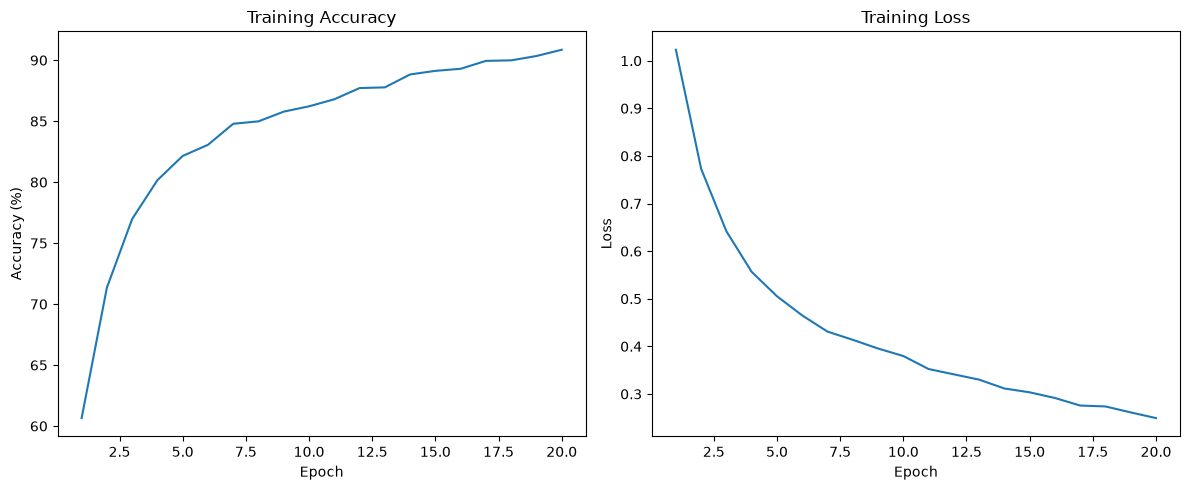

In [23]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

In [26]:
class_names = train_dataset.classes

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


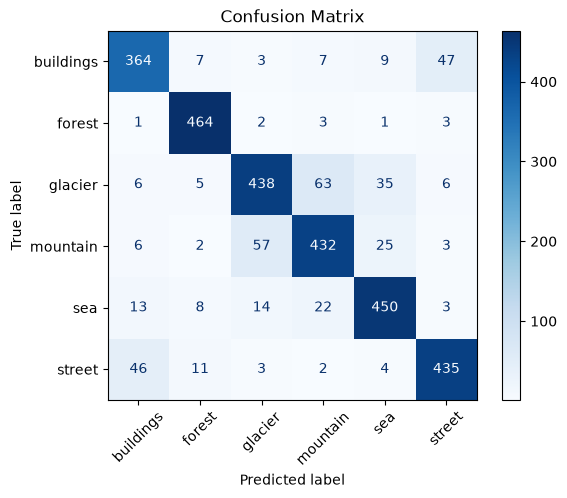

In [27]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.83      0.83      0.83       437
      forest       0.93      0.98      0.96       474
     glacier       0.85      0.79      0.82       553
    mountain       0.82      0.82      0.82       525
         sea       0.86      0.88      0.87       510
      street       0.88      0.87      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



In [29]:
images, labels = next(iter(test_loader))

images_device = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images_device)
    predictions = outputs.argmax(dim=1).cpu()

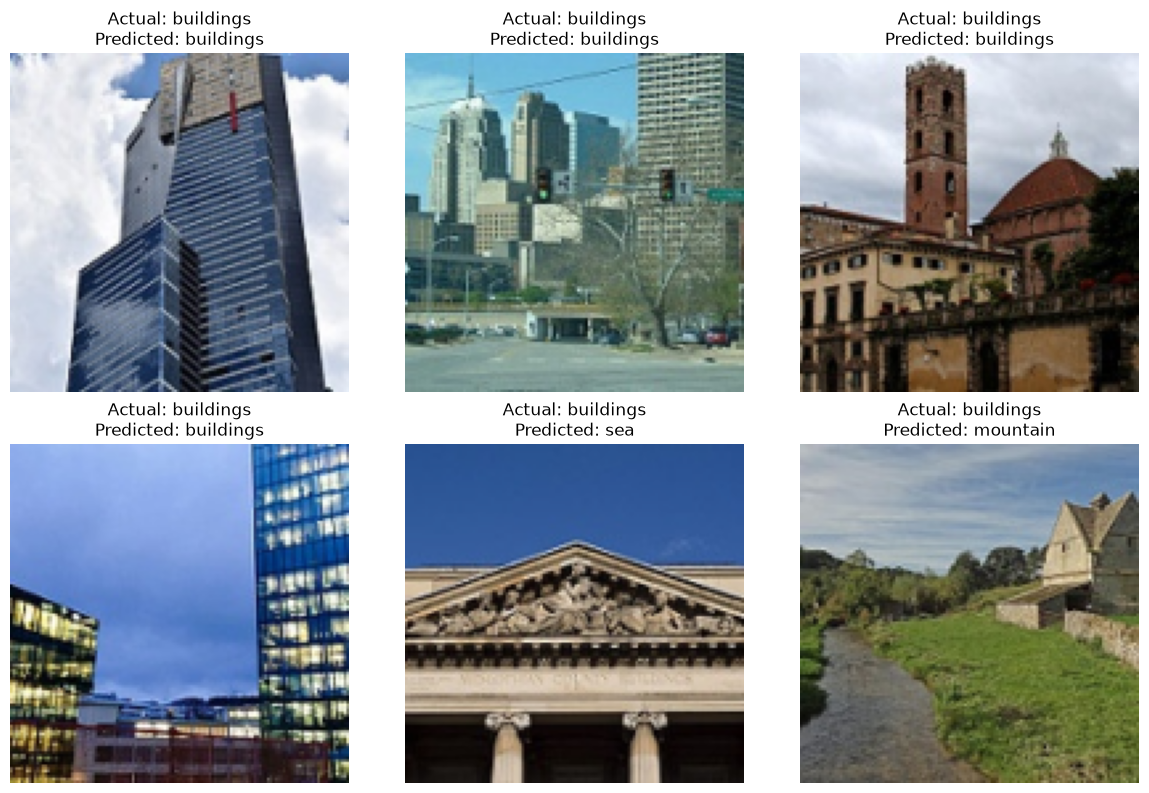

In [30]:
plt.figure(figsize=(12, 8))

for i in range(6):

    image = images[i]

    # Reverse normalization
    image = image * 0.5 + 0.5

    image = image.permute(1, 2, 0)

    plt.subplot(2, 3, i + 1)

    plt.imshow(image.numpy())

    actual = class_names[labels[i]]
    predicted = class_names[predictions[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### save the model

In [33]:
torch.save(
    model.state_dict(),
    "cnn_pytorch.pth"
)

print("Model saved successfully.")

Model saved successfully.


In [34]:
loaded_model = CNN()

In [35]:
loaded_model.load_state_dict(
    torch.load(
        "cnn_pytorch.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [36]:
loaded_model = loaded_model.to(device)

In [37]:
loaded_model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12544, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)